### 1 задание
Напишите функцию для подсчета количества параметров в сверточном слое. Ваша функция должна принимать на вход количество входных каналов, количество выходных каналов, размер ядра и стоит ли делать обучаемый сдвиг. 

Сделайте для нее такую сигнатуру:

```def count_parameters_conv(in_channels: int, out_channels: int, kernel_size: int, bias: bool):```

In [20]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
from IPython.display import clear_output
from PIL import Image
from matplotlib import cm
from time import perf_counter
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from tqdm import tqdm

warnings.filterwarnings('ignore')

plt.rc('font', size=30)

In [21]:
def count_parameters_conv(in_channels:int, out_channels:int, kernel_size:int, bias:bool):
    c1 = in_channels
    c2 = out_channels
    c3 = kernel_size
    if bias == true:
        amount_params = (c1*c3**2 + 1)*c2
    else:
        amount_params = c1*c3**2*c2
    return amount_params    

### 2-3 задание
**Обучите свою первую нейронную сеть!**
Обучите сверточную нейронную сеть для классификации на датасете MNIST. Добейтесь качества в 99.3% на тестовой выборке.

Можете использовать уже написанные ранее функции train и evaluate.

Чтобы мы могли проверить вашу модель, напишите функцию, которая создает вашу модель и возвращает объект, назовите функцию create_conv_model, без аргументов. Вам понадобится сохранить веса вашей модели и сдать их в тестировщик, для этого воспользуйтесь методами torch.save и state_dict.

In [84]:
mnist_train = MNIST(
    "DEEP LEARNING/datasets/mnist",
    train=True,
    download=True,
    transform=T.ToTensor()
)

mnist_valid = MNIST(
    "DEEP LEARNING/datasets/mnist",
    train=False,
    download=True,
    transform=T.ToTensor()
)

train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)
valid_loader = DataLoader(mnist_valid, batch_size=64, shuffle=False)

In [85]:
def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn):
    model.train() ### перевод в режим обучения
    loss_1 = 0 ### задаем начало подсчета лосса
    for x,y in tqdm(data_loader): ### итерируемся по даталоадеру, можно было и без tqdm 
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad() ### зануляем градиенты
        output = model(x) ### считаем выходы
        loss = loss_fn(output, y) ### считаем ошибку
        
        loss_1 += loss.item() ### добавляем ошибку
        
        loss.backward() ### делаем обратный проход, считаем градиенты
        print(f"{loss.item():.5f}") ### печатаем текущую ошибку
        optimizer.step() ### делаем шаг оптимизатора, обновляя веса модели..
    
    train_loss = loss_1/(len(data_loader)) ### усредняем ошибку
    return train_loss   ### возвращаем усредненную ошибку


In [86]:
@torch.inference_mode() ### навешиваем декоратор для запрета подсчета градиентов
def evaluate(model:nn.Module, data_loader:DataLoader, loss_fn):
    model.eval() ### на всякий случай включаем модель в режим eval
    loss_all = 0 ### начало подсчета ошибки
    correct = 0
    total = 0
    
    for x,y in tqdm(data_loader): ### итерируемся
        x = x.to(device)
        y = y.to(device)
                 
        output = model(x) ### форврад пасс
        loss = loss_fn(output, y) ### считаем ошибку
        
        loss_all +=loss.item() ### добавляем ошибку

        preds = output.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        
    total_loss = loss_all/(len(data_loader)) ### считаем среднее
    accuracy = correct / total
    return total_loss, accuracy ### возвращаем среднюю ошибку

In [87]:
x, y = next(iter(train_loader))
print(x.shape)
print(y.shape)


torch.Size([64, 1, 28, 28])
torch.Size([64])


In [88]:
def create_conv_model():
    first_model = nn.Sequential(
        nn.Conv2d(1, 32, 3), ### ВХОД: 1 канал и 28х28 изображения -> фильтр 3х3 -> 32 канала, 26x26 изображения 
        nn.ReLU(),

        nn.Conv2d(32, 128, 3, padding=1), ### 32x26x26 -> фильтр 2х2 -> 128x26x26
        nn.ReLU(),

        nn.Conv2d(128, 256, 7), ### 128x26x26 -> фильтр 7х7 -> 256x20x20
        nn.ReLU(),
        nn.MaxPool2d(2), ### 256x10x10

        nn.Conv2d(256, 64, 3), ### 256x10x10 -> фильтр 3x3 -> 64x8x8
        nn.ReLU(),
        nn.MaxPool2d(2), ### 64x4x4

        nn.Flatten(), ### 64*4*4=1024

        nn.Linear(64*4*4,512),  ### 1024 -> 512
        nn.ReLU(),
        nn.Linear(512,128), ### 512 -> 128
        nn.ReLU(),
        nn.Linear(128,10) ### 128 -> 10       
    )
    return first_model

In [89]:
### функция для обрисовки графиков с ошибкой, качества
def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()
    plt.grid()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')

    plt.plot(valid_accuracy)
    plt.grid()

    plt.show()



In [90]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)
print(torch.cuda.get_device_name())

first_model = create_conv_model().to(device)
optimizer = torch.optim.Adam(first_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

cuda:0
NVIDIA GeForce RTX 2060


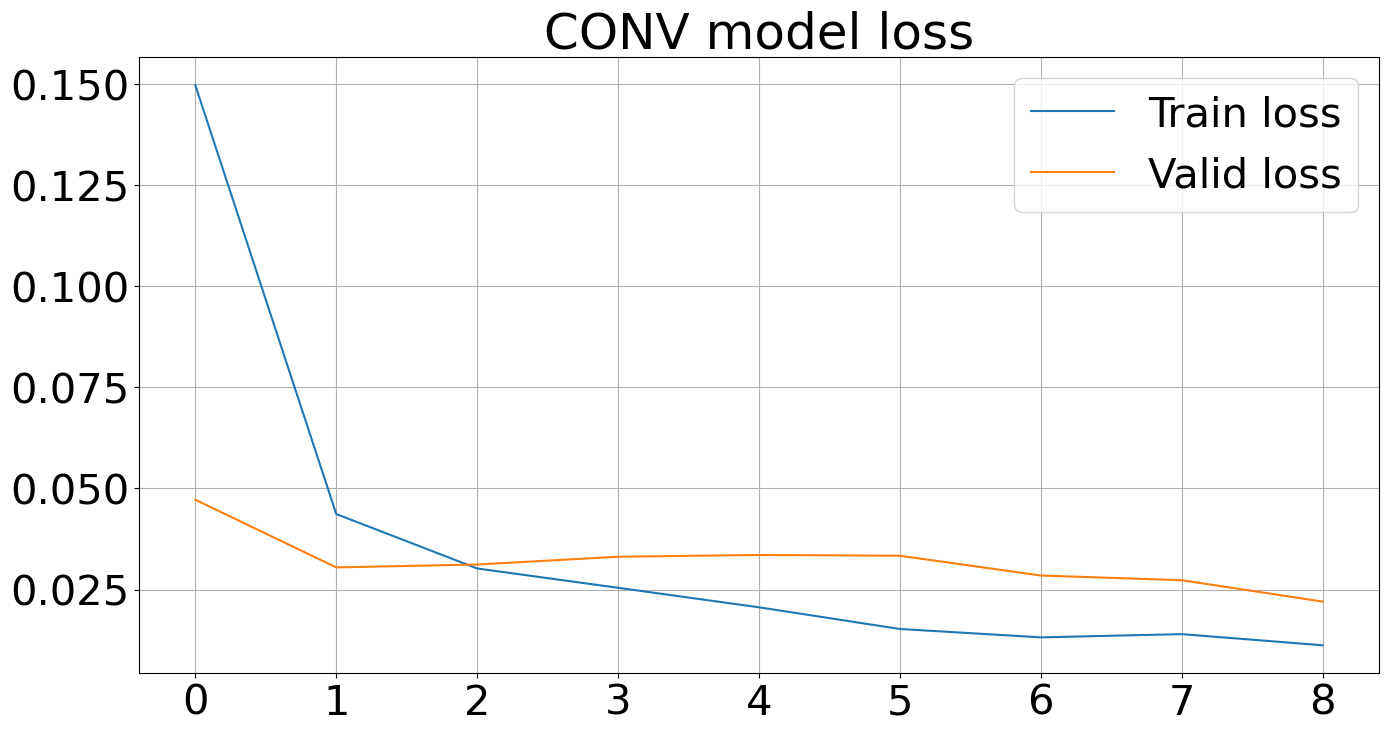

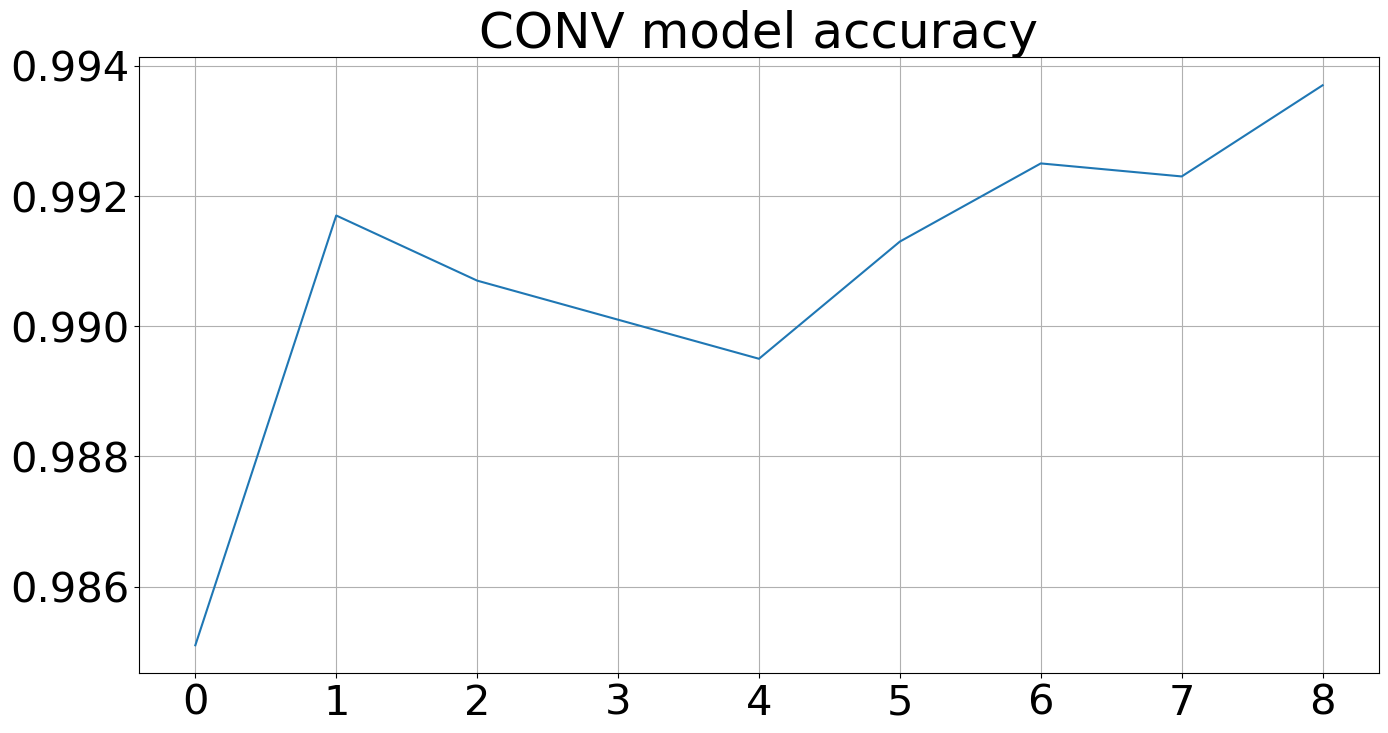

Достигнута точность 0.994, останавливаем обучение
Total training and evaluation time 322.20067


In [91]:
num_epochs = 15

train_loss_history, valid_loss_history = [], []
valid_accuracy_history = []

start = perf_counter()



for epoch in range(num_epochs):
    
    train_loss = train(first_model,train_loader, optimizer, loss_fn)

    valid_loss, valid_accuracy = evaluate(first_model, valid_loader, loss_fn)

    train_loss_history.append(train_loss)
    valid_loss_history.append(valid_loss)
    valid_accuracy_history.append(valid_accuracy)

    clear_output()

    plot_stats(train_loss_history, valid_loss_history, valid_accuracy_history, 'CONV model')

    if valid_accuracy_history[-1] >= 0.993:
        print(f"Достигнута точность {valid_accuracy_history[-1]:.3f}, останавливаем обучение")
        break

print(f'Total training and evaluation time {perf_counter() - start:.5f}')

In [92]:
first_model.state_dict()

OrderedDict([('0.weight',
              tensor([[[[-1.9948e-01,  1.6895e-01, -6.3896e-02],
                        [ 3.8726e-01, -1.9588e-01, -1.4398e-01],
                        [-5.7226e-02, -2.0224e-01, -4.7611e-01]]],
              
              
                      [[[ 1.8370e-01, -1.2800e-01,  9.6966e-02],
                        [-6.7265e-02,  7.5306e-02,  2.3592e-01],
                        [-4.3891e-01,  1.1227e-01,  2.5744e-02]]],
              
              
                      [[[ 1.9857e-01, -2.5325e-01,  2.1006e-01],
                        [-1.4804e-01, -1.5740e-01,  1.6505e-01],
                        [-3.9236e-01,  1.8979e-01, -2.9981e-01]]],
              
              
                      [[[-2.6987e-01, -1.4938e-01,  4.8790e-02],
                        [ 1.0769e-01,  2.3356e-01,  2.0345e-01],
                        [-1.4450e-02, -2.1310e-01, -1.2280e-01]]],
              
              
                      [[[-2.4649e-01, -4.0660e-02, -3.6829e-01],
 

In [93]:
torch.save(first_model.state_dict(), "mnist_conv_weights.pth")